# SETUP

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Importing Libraries</b>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# LOADING DATASET

In [2]:
url = "../data/heart_disease.csv"

df = pd.read_csv(url)


print("Shape:", df.shape)
print(df.head())

Shape: (302, 14)
   63.0  1.0  1.0.1  145.0  233.0  1.0.2  2.0  150.0  0.0  2.3  3.0 0.0.1  \
0  67.0  1.0    4.0  160.0  286.0    0.0  2.0  108.0  1.0  1.5  2.0   3.0   
1  67.0  1.0    4.0  120.0  229.0    0.0  2.0  129.0  1.0  2.6  2.0   2.0   
2  37.0  1.0    3.0  130.0  250.0    0.0  0.0  187.0  0.0  3.5  3.0   0.0   
3  41.0  0.0    2.0  130.0  204.0    0.0  2.0  172.0  0.0  1.4  1.0   0.0   
4  56.0  1.0    2.0  120.0  236.0    0.0  0.0  178.0  0.0  0.8  1.0   0.0   

   6.0  0  
0  3.0  2  
1  7.0  1  
2  3.0  0  
3  3.0  0  
4  3.0  0  


# 1. Handle Missing Values (in this dataset, "?" is used)

In [3]:
df = df.replace("?", np.nan)
df = df.dropna()  
df = df.astype(float)

# 2. Separate features and target

In [4]:
X = df.iloc[:, :-1]  
y = df.iloc[:, -1]

# 3. Standardize Features


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply PCA

In [6]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 5. Explained Variance


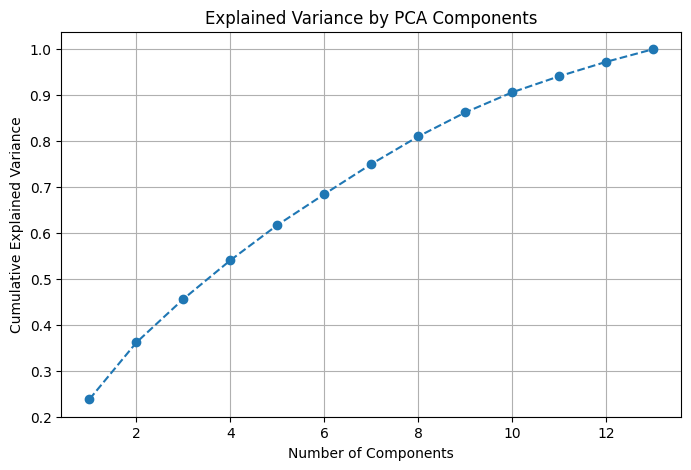

Explained variance ratio per component: [0.23787068 0.12361389 0.09463433 0.08429501 0.07661924 0.06730129
 0.06550421 0.0601563  0.0523263  0.04383256 0.03495608 0.03139356
 0.02749655]
Cumulative variance: [0.23787068 0.36148457 0.4561189  0.54041391 0.61703315 0.68433444
 0.74983866 0.80999495 0.86232125 0.90615381 0.94110989 0.97250345
 1.        ]


In [7]:
explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Cumulative variance:", explained_var)

# 6. Choose optimal components (e.g., 95% variance)


In [8]:
pca_opt = PCA(n_components=0.95)  # keep 95% variance
X_pca_opt = pca_opt.fit_transform(X_scaled)

print("Optimal number of components:", pca_opt.n_components_)
print("Transformed dataset shape:", X_pca_opt.shape)

Optimal number of components: 12
Transformed dataset shape: (296, 12)


# 7. Scatter plot (first 2 components for visualization)


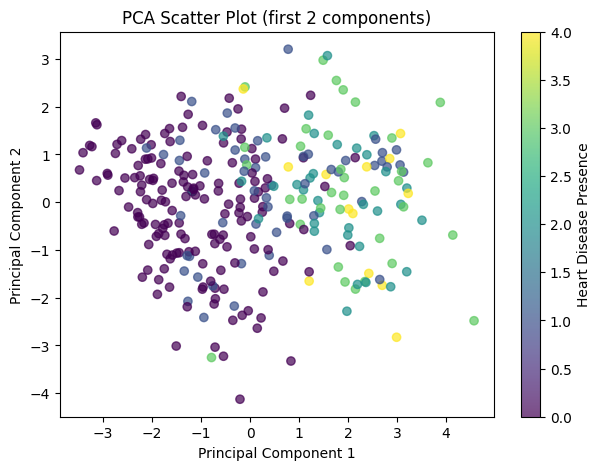

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca_opt[:,0], X_pca_opt[:,1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot (first 2 components)")
plt.colorbar(label="Heart Disease Presence")
plt.show()